In [1]:
import cv2
import mediapipe as mp
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.spatial import distance as dist
import time

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import FaceLandmarker, FaceLandmarkerOptions, RunningMode

EAR_THRESHOLD = 0.25
CONSEC_FRAMES = 3

In [2]:
def process_video_for_blink_rate(video_path):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30.0
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    blink_count = 0
    processed_frames = 0
    face_detected_count = 0
    blink_active = False
    
    sample_frame = None
    frame_skip = 2
    
    # Enable blendshapes as it is more accurate with glasses
    base_options = mp.tasks.BaseOptions(model_asset_path="face_landmarker.task")
    
    options = FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=RunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.35,
        min_face_presence_confidence=0.35,
        min_tracking_confidence=0.35,
        output_face_blendshapes=True
    )
    
    print(f"Starting blink detection on {video_path.name} (using blendshapes)")
    print(f"  Frames: {total_frames} | Duration: ~{total_frames/fps:.1f} sec")
    
    with FaceLandmarker.create_from_options(options) as landmarker:
        last_print_time = time.time()
        early_print_count = 0
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
                
            processed_frames += 1
            
            if (processed_frames - 1) % frame_skip != 0:
                continue
            
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            timestamp_ms = int(processed_frames * (1000 / fps))
            
            result = landmarker.detect_for_video(mp_image, timestamp_ms)
            
            if result.face_landmarks and len(result.face_landmarks) > 0 and result.face_blendshapes:
                face_detected_count += 1
                blendshapes = result.face_blendshapes[0]
                
                # Get eye blink scores (0.0 = open, ~1.0 = closed)
                eye_blink_left = next((bs.score for bs in blendshapes if bs.category_name == "eyeBlinkLeft"), 0.0)
                eye_blink_right = next((bs.score for bs in blendshapes if bs.category_name == "eyeBlinkRight"), 0.0)
                avg_blink_score = (eye_blink_left + eye_blink_right) / 2.0
                
                # Count blink when score goes high and then drops (simple state machine)
                if avg_blink_score > 0.6 and not blink_active:
                    blink_active = True
                elif avg_blink_score < 0.3 and blink_active:
                    blink_count += 1
                    blink_active = False
                
                # Save sample frame with landmarks
                if sample_frame is None and face_detected_count > 30:
                    sample_frame = frame.copy()
                    annotated = frame.copy()
                    for lm in result.face_landmarks[0]:
                        x = int(lm.x * frame.shape[1])
                        y = int(lm.y * frame.shape[0])
                        cv2.circle(annotated, (x, y), 2, (0, 255, 0), -1)
                    sample_frame = annotated
            
            # Progress
            if time.time() - last_print_time > (6 if early_print_count < 4 else 10):
                progress = (processed_frames / total_frames) * 100
                print(f"  Progress: {progress:.1f}%  |  Blinks so far: {blink_count}  |  Face frames: {face_detected_count}")
                last_print_time = time.time()
                early_print_count += 1
    
    cap.release()
    
    duration_seconds = total_frames / fps if fps > 0 else 1.0
    blink_rate_per_sec = blink_count / duration_seconds if duration_seconds > 0 else 0.0
    
    print(f"Finished {video_path.name} → {blink_count} blinks detected ({blink_rate_per_sec:.4f} blinks/sec | {blink_rate_per_sec*60:.1f} blinks/min)")
    
    return {
        'video': video_path.name,
        'total_blinks': blink_count,
        'duration_sec': round(duration_seconds, 2),
        'blink_rate_per_sec': round(blink_rate_per_sec, 4),
        'blink_rate_per_min': round(blink_rate_per_sec * 60, 2),
        'sample_frame': sample_frame
    }

Found 2 video(s):
 - GX010751.MP4
 - GX010754.MP4

Processing GX010751.MP4 for blink rate...
Starting blink detection on GX010751.MP4 (using blendshapes)
  Frames: 12313 | Duration: ~410.8 sec
  Progress: 1.9%  |  Blinks so far: 2  |  Face frames: 117
  Progress: 3.9%  |  Blinks so far: 2  |  Face frames: 234
  Progress: 5.8%  |  Blinks so far: 3  |  Face frames: 355
  Progress: 7.8%  |  Blinks so far: 3  |  Face frames: 475
  Progress: 11.1%  |  Blinks so far: 3  |  Face frames: 676
  Progress: 14.3%  |  Blinks so far: 4  |  Face frames: 877
  Progress: 17.6%  |  Blinks so far: 5  |  Face frames: 1076
  Progress: 20.8%  |  Blinks so far: 7  |  Face frames: 1276
  Progress: 24.0%  |  Blinks so far: 9  |  Face frames: 1475
  Progress: 27.4%  |  Blinks so far: 10  |  Face frames: 1682
  Progress: 30.7%  |  Blinks so far: 11  |  Face frames: 1884
  Progress: 33.9%  |  Blinks so far: 14  |  Face frames: 2085
  Progress: 37.2%  |  Blinks so far: 19  |  Face frames: 2284
  Progress: 40.5%  |

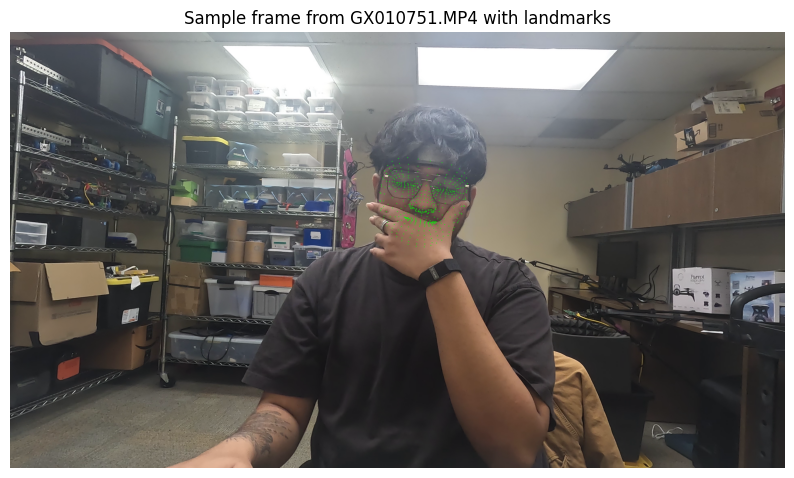

 Blinks detected: 72
 Duration: 410.84 seconds
 Blink rate: 0.1752 blinks/sec (10.51 blinks/min)

Processing GX010754.MP4 for blink rate...
Starting blink detection on GX010754.MP4 (using blendshapes)
  Frames: 16067 | Duration: ~536.1 sec
  Progress: 1.5%  |  Blinks so far: 3  |  Face frames: 106
  Progress: 3.0%  |  Blinks so far: 3  |  Face frames: 232
  Progress: 4.5%  |  Blinks so far: 3  |  Face frames: 351
  Progress: 6.0%  |  Blinks so far: 5  |  Face frames: 471
  Progress: 8.5%  |  Blinks so far: 9  |  Face frames: 673
  Progress: 11.0%  |  Blinks so far: 13  |  Face frames: 873
  Progress: 13.5%  |  Blinks so far: 15  |  Face frames: 1071
  Progress: 15.9%  |  Blinks so far: 17  |  Face frames: 1267
  Progress: 18.4%  |  Blinks so far: 17  |  Face frames: 1465
  Progress: 20.8%  |  Blinks so far: 18  |  Face frames: 1661
  Progress: 23.3%  |  Blinks so far: 19  |  Face frames: 1858
  Progress: 25.8%  |  Blinks so far: 22  |  Face frames: 2058
  Progress: 29.0%  |  Blinks so 

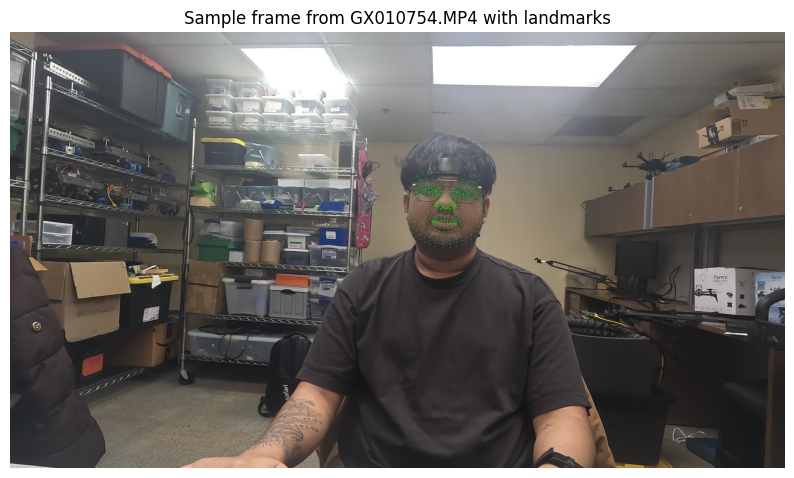

 Blinks detected: 55
 Duration: 536.1 seconds
 Blink rate: 0.1026 blinks/sec (6.16 blinks/min)

Overall average blink rate across all videos: 0.1389 blinks per second


In [3]:
video_folder = Path("videos")
video_files = sorted(list(video_folder.glob("*.mp4")))

print(f"Found {len(video_files)} video(s):")
for v in video_files:
    print(f" - {v.name}")

results_a = []
for video_path in video_files:
    print(f"\nProcessing {video_path.name} for blink rate...")
    result = process_video_for_blink_rate(video_path)
    results_a.append(result)
    
    if result['sample_frame'] is not None:
        plt.figure(figsize=(10, 6))
        rgb_sample = cv2.cvtColor(result['sample_frame'], cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_sample)
        plt.title(f"Sample frame from {result['video']} with landmarks")
        plt.axis('off')
        plt.show()
    
    print(f" Blinks detected: {result['total_blinks']}")
    print(f" Duration: {result['duration_sec']} seconds")
    print(f" Blink rate: {result['blink_rate_per_sec']} blinks/sec ({result['blink_rate_per_min']} blinks/min)")

if results_a:
    avg_rate = np.mean([r['blink_rate_per_sec'] for r in results_a])
    print(f"\nOverall average blink rate across all videos: {avg_rate:.4f} blinks per second")


Processing GX010751.MP4 for dimensions...


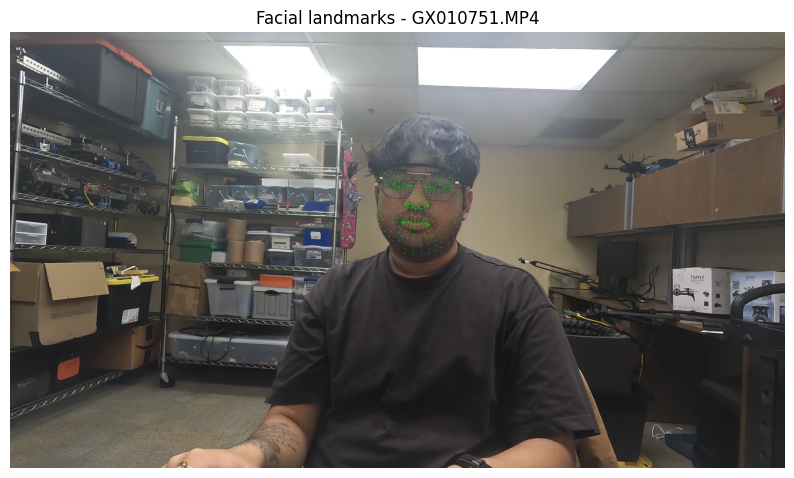

  Face height: 16.8 cm
  Face width (ear to ear): 14.5 cm
  Eye width: 2.7 cm
  Nose length: 3.3 cm
  Mouth width: 4.8 cm

Processing GX010754.MP4 for dimensions...


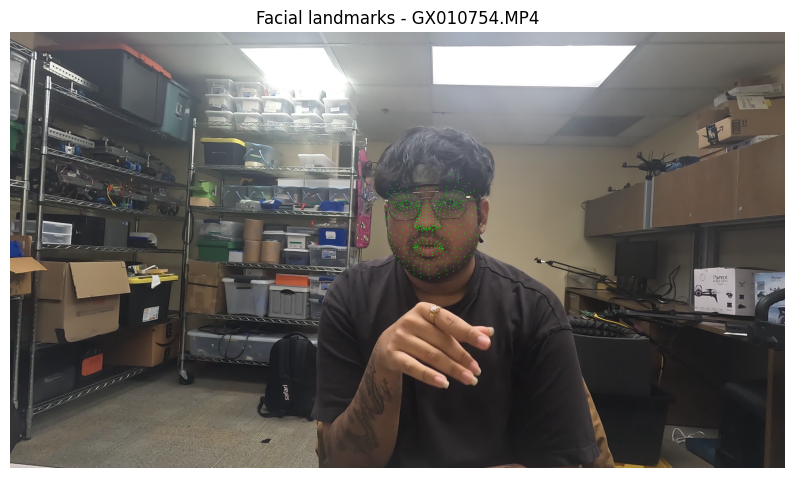

  Face height: 16.5 cm
  Face width (ear to ear): 14.5 cm
  Eye width: 2.8 cm
  Nose length: 3.4 cm
  Mouth width: 4.8 cm

Average Facial Dimensions Across Videos
  Face Height Cm: 16.6 cm
  Face Width Cm: 14.5 cm
  Eye Width Cm: 2.8 cm
  Nose Length Cm: 3.4 cm
  Mouth Width Cm: 4.8 cm


In [4]:
def estimate_facial_dimensions(landmarks, frame_shape):
    """Estimate dimensions using MediaPipe landmarks + approximate scale."""
    h, w = frame_shape[:2]
    
    # Key landmark indices
    forehead_idx = 10
    chin_idx = 152
    left_ear_idx = 234
    right_ear_idx = 454
    left_eye_outer = 33
    left_eye_inner = 133
    nose_bridge = 168
    nose_tip = 4
    mouth_left = 61
    mouth_right = 291
    
    def pixel_dist(idx1, idx2):
        p1 = np.array([landmarks[idx1].x * w, landmarks[idx1].y * h])
        p2 = np.array([landmarks[idx2].x * w, landmarks[idx2].y * h])
        return np.linalg.norm(p1 - p2)
    
    face_height_px = pixel_dist(forehead_idx, chin_idx)
    face_width_px = pixel_dist(left_ear_idx, right_ear_idx)
    eye_width_px = pixel_dist(left_eye_outer, left_eye_inner)
    nose_length_px = pixel_dist(nose_bridge, nose_tip)
    mouth_width_px = pixel_dist(mouth_left, mouth_right)
    
    # Rough scale: assume average adult bizygomatic width ≈ 14.5 cm
    scale_cm_per_px = 14.5 / face_width_px if face_width_px > 50 else 0.1
    
    return {
        'face_height_cm': round(face_height_px * scale_cm_per_px, 1),
        'face_width_cm': round(face_width_px * scale_cm_per_px, 1),
        'eye_width_cm': round(eye_width_px * scale_cm_per_px, 1),
        'nose_length_cm': round(nose_length_px * scale_cm_per_px, 1),
        'mouth_width_cm': round(mouth_width_px * scale_cm_per_px, 1),
        'scale_cm_per_px': round(scale_cm_per_px, 4)
    }

results_b = []
for video_path in video_files:
    print(f"\nProcessing {video_path.name} for dimensions...")
    cap = cv2.VideoCapture(str(video_path))
    
    # Take a frame from the middle (more likely good frontal view)
    mid_frame = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) // 2)
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame)
    ret, frame = cap.read()
    cap.release()
    
    if not ret:
        print(f"  Could not read frame from {video_path.name}")
        continue
    
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    base_options = mp.tasks.BaseOptions(model_asset_path="face_landmarker.task")
    options = FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=RunningMode.IMAGE,
        num_faces=1,
        min_face_detection_confidence=0.5
    )
    
    with FaceLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)
        
        if result.face_landmarks and len(result.face_landmarks) > 0:
            landmarks = result.face_landmarks[0]
            dims = estimate_facial_dimensions(landmarks, frame.shape)
            
            results_b.append({
                'video': video_path.name,
                **dims
            })
            
            # Show annotated frame
            annotated = frame.copy()
            for lm in landmarks:
                x = int(lm.x * frame.shape[1])
                y = int(lm.y * frame.shape[0])
                cv2.circle(annotated, (x, y), 2, (0, 255, 0), -1)
            
            plt.figure(figsize=(10, 7))
            plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            plt.title(f"Facial landmarks - {video_path.name}")
            plt.axis('off')
            plt.show()
            
            print(f"  Face height: {dims['face_height_cm']} cm")
            print(f"  Face width (ear to ear): {dims['face_width_cm']} cm")
            print(f"  Eye width: {dims['eye_width_cm']} cm")
            print(f"  Nose length: {dims['nose_length_cm']} cm")
            print(f"  Mouth width: {dims['mouth_width_cm']} cm")
        else:
            print(f"  No face detected in middle frame of {video_path.name}")

# Summary for Task B
if results_b:
    print("\nAverage Facial Dimensions Across Videos")
    avg_dims = {}
    for key in ['face_height_cm', 'face_width_cm', 'eye_width_cm', 'nose_length_cm', 'mouth_width_cm']:
        values = [r[key] for r in results_b]
        avg_dims[key] = round(np.mean(values), 1)
        print(f"  {key.replace('_', ' ').title()}: {avg_dims[key]} cm")

In [5]:
print("FINAL RESULTS")

print("\nTask A - Blink Rate (during study):")
for r in results_a:
    print(f"  {r['video']}:")
    print(f"    Total blinks: {r['total_blinks']}")
    print(f"    Duration: {r['duration_sec']} seconds")
    print(f"    Blink rate: {r['blink_rate_per_sec']:.4f} blinks/sec ({r['blink_rate_per_min']:.1f} blinks/min)")

if results_a:
    overall_avg = np.mean([r['blink_rate_per_min'] for r in results_a])
    print(f"\nOverall average blink rate: {overall_avg:.1f} blinks per minute")

print("\nTask B - Facial Dimensions (approximate):")
if results_b:
    for r in results_b:
        print(f"  {r['video']}:")
        print(f"    Face height: {r['face_height_cm']} cm")
        print(f"    Face width:  {r['face_width_cm']} cm")
        print(f"    Eye width:   {r['eye_width_cm']} cm")
        print(f"    Nose length: {r['nose_length_cm']} cm")
        print(f"    Mouth width: {r['mouth_width_cm']} cm")
    
    print("\nAverages:")
    for key in ['face_height_cm', 'face_width_cm', 'eye_width_cm', 'nose_length_cm', 'mouth_width_cm']:
        avg = round(np.mean([r[key] for r in results_b]), 1)
        print(f"  {key.replace('_', ' ').title()}: {avg} cm")
else:
    print("  No dimensions calculated.")

FINAL RESULTS

Task A - Blink Rate (during study):
  GX010751.MP4:
    Total blinks: 72
    Duration: 410.84 seconds
    Blink rate: 0.1752 blinks/sec (10.5 blinks/min)
  GX010754.MP4:
    Total blinks: 55
    Duration: 536.1 seconds
    Blink rate: 0.1026 blinks/sec (6.2 blinks/min)

Overall average blink rate: 8.3 blinks per minute

Task B - Facial Dimensions (approximate):
  GX010751.MP4:
    Face height: 16.8 cm
    Face width:  14.5 cm
    Eye width:   2.7 cm
    Nose length: 3.3 cm
    Mouth width: 4.8 cm
  GX010754.MP4:
    Face height: 16.5 cm
    Face width:  14.5 cm
    Eye width:   2.8 cm
    Nose length: 3.4 cm
    Mouth width: 4.8 cm

Averages:
  Face Height Cm: 16.6 cm
  Face Width Cm: 14.5 cm
  Eye Width Cm: 2.8 cm
  Nose Length Cm: 3.4 cm
  Mouth Width Cm: 4.8 cm
